# Análisis Estadístico Dataset Parkinson

Carga y limpieza de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data"
df = pd.read_csv(url)
display(df.head())

dimensiones_antes = df.shape
df = df.replace('?', np.nan)
valores_faltantes = df.isna().sum()
print("Valores faltantes por columna:")
print(valores_faltantes)
print("\n")
df = df.dropna()
dimensiones_despues = df.shape
print("Resumen de Dimensiones:")
print(f"Dimensiones ANTES de la limpieza: {dimensiones_antes}")
print(f"Dimensiones DESPUÉS de la limpieza: {dimensiones_despues}")

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


Valores faltantes por columna:
subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64


Resumen de Dimensiones:
Dimensiones ANTES de la limpieza: (5875, 22)
Dimensiones DESPUÉS de la limpieza: (5875, 22)


Identificación de atributos

In [2]:
#Tipos detectados por pandas
tipos_pandas = df.dtypes
print("Tipos de datos detectados por Pandas:")
print(tipos_pandas)

# Clasificación teórica
  # 1. Definimos los tipos teóricos
tipos_teoricos = {
    'subject#': 'Nominal',
    'age': 'Numérico',
    'sex': 'Binario',
    'test_time': 'Numérico',
    'motor_UPDRS': 'Numérico',
    'total_UPDRS': 'Numérico',
    'Jitter(%)': 'Numérico',
    'Jitter(Abs)': 'Numérico',
    'Jitter:RAP': 'Numérico',
    'Jitter:PPQ5': 'Numérico',
    'Jitter:DDP': 'Numérico',
    'Shimmer': 'Numérico',
    'Shimmer(dB)': 'Numérico',
    'Shimmer:APQ3': 'Numérico',
    'Shimmer:APQ5': 'Numérico',
    'Shimmer:APQ11': 'Numérico',
    'Shimmer:DDA': 'Numérico',
    'NHR': 'Numérico',
    'HNR': 'Numérico',
    'RPDE': 'Numérico',
    'DFA': 'Numérico',
    'PPE': 'Numérico'
}
   # 2. Extraemos los datos
nombres_columnas = df.columns
tipos_pandas = df.dtypes.values
valores_unicos = df.nunique().values

   # 3. Creamos un nuevo DataFrame para mostrar tabla 
tabla_clasificacion = pd.DataFrame({
    'Nombre del atributo': nombres_columnas,
    'Tipo teórico': [tipos_teoricos[col] for col in nombres_columnas],
    'Tipo detectado por pandas': tipos_pandas,
    'Número de valores únicos': valores_unicos
})

   # 4. Mostramos la tabla 
print(" Tabla de Clasificación Teórica ")
display(tabla_clasificacion)

Tipos de datos detectados por Pandas:
subject#           int64
age                int64
sex                int64
test_time        float64
motor_UPDRS      float64
total_UPDRS      float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64
dtype: object
 Tabla de Clasificación Teórica 


,Nombre del atributo,Tipo teórico,Tipo detectado por pandas,Número de valores únicos
0,subject#,Nominal,int64,42
1,age,Numérico,int64,23
2,sex,Binario,int64,2
3,test_time,Numérico,float64,2442
4,motor_UPDRS,Numérico,float64,1080
5,total_UPDRS,Numérico,float64,1129
6,Jitter(%),Numérico,float64,1305
7,Jitter(Abs),Numérico,float64,4105
8,Jitter:RAP,Numérico,float64,853
9,Jitter:PPQ5,Numérico,float64,840


Estadísticas

In [3]:
estadisticas = df.describe()
display(estadisticas)

# Tendencia Central
  # 1. Cálculos para la variable 'age'
print(" Tendencia Central para la variable 'age' ")
media_age = df['age'].mean()
mediana_age = df['age'].median()
moda_age = df['age'].mode()[0]

print(f"Media: {media_age:.2f}")
print(f"Mediana: {mediana_age}")
print(f"Moda: {moda_age}\n")

  # 2. Cálculos para una segunda variable (total_UPDRS)
print(" Tendencia Central para la variable 'total_UPDRS' ")
media_updrs = df['total_UPDRS'].mean()
mediana_updrs = df['total_UPDRS'].median()
moda_updrs = df['total_UPDRS'].mode()[0]

print(f"Media: {media_updrs:.2f}")
print(f"Mediana: {mediana_updrs}")
print(f"Moda: {moda_updrs}")

# Dispersión
print(" Medidas de Dispersión para la variable 'total_UPDRS' ")
   # Rango (Máximo - Mínimo)
rango = df['total_UPDRS'].max() - df['total_UPDRS'].min()

   # Cuartiles y IQR
q1 = df['total_UPDRS'].quantile(0.25)
q3 = df['total_UPDRS'].quantile(0.75)
iqr = q3 - q1

   # Varianza y Desviación Estándar
varianza = df['total_UPDRS'].var()
desviacion_estandar = df['total_UPDRS'].std()

   # Imprimir resultados
print(f"Rango: {rango:.2f}")
print(f"Q1 (Primer Cuartil, 25%): {q1:.2f}")
print(f"Q3 (Tercer Cuartil, 75%): {q3:.2f}")
print(f"IQR (Rango Intercuartílico): {iqr:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desviacion_estandar:.2f}")

# Frecuencias en categóricas
# Usamos 'subject#' (Identificador Nominal del paciente)
print(" Top-10 de pacientes con más registros en el dataset ")
top10_pacientes = df['subject#'].value_counts().head(10)
display(top10_pacientes)

# Agregamos 'sex' (Binario)
print("\n Frecuencia de la variable categórica 'sex' ")
frecuencia_sexo = df['sex'].value_counts()
display(frecuencia_sexo)

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


 Tendencia Central para la variable 'age' 
Media: 64.80
Mediana: 65.0
Moda: 58

 Tendencia Central para la variable 'total_UPDRS' 
Media: 29.02
Mediana: 27.576
Moda: 32.0
 Medidas de Dispersión para la variable 'total_UPDRS' 
Rango: 47.99
Q1 (Primer Cuartil, 25%): 21.37
Q3 (Tercer Cuartil, 75%): 36.40
IQR (Rango Intercuartílico): 15.03
Varianza: 114.50
Desviación estándar: 10.70
 Top-10 de pacientes con más registros en el dataset 


subject#
29    168
35    165
41    165
34    161
7     161
24    156
5     156
6     156
9     152
8     150
Name: count, dtype: int64


 Frecuencia de la variable categórica 'sex' 


sex
0    4008
1    1867
Name: count, dtype: int64

Visualización gráfica

Histograma y Densidad (KDE) de 'age' 


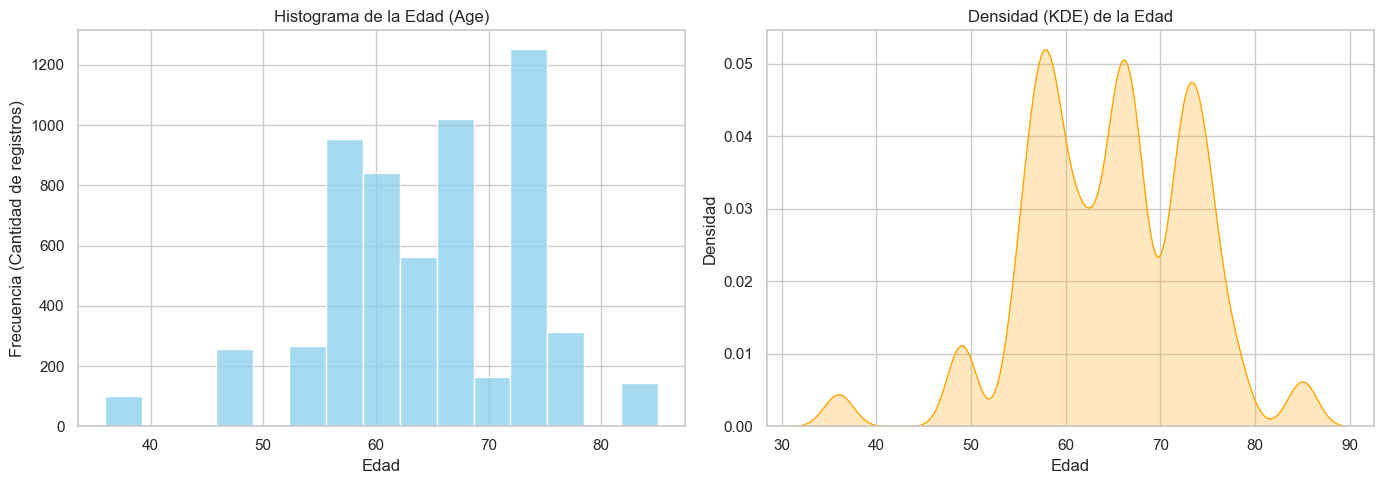

Boxplot para múltiples variables


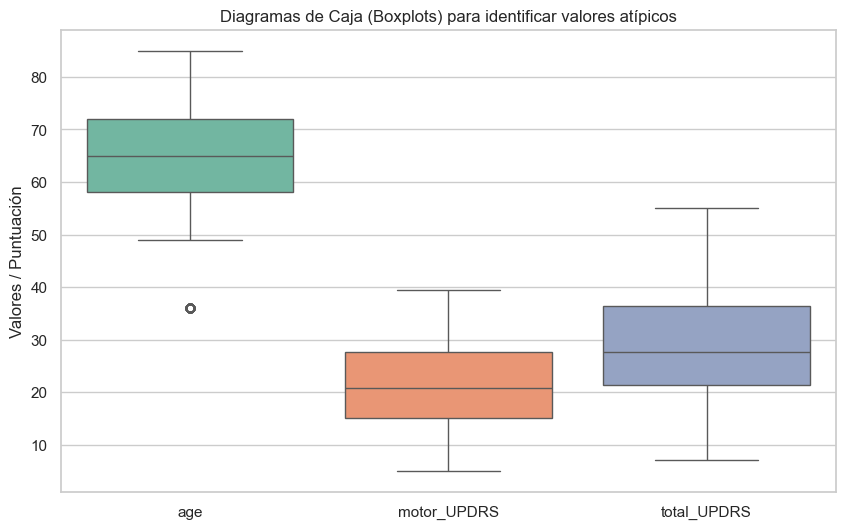

Scatter Plot (Edad vs Total UPDRS)


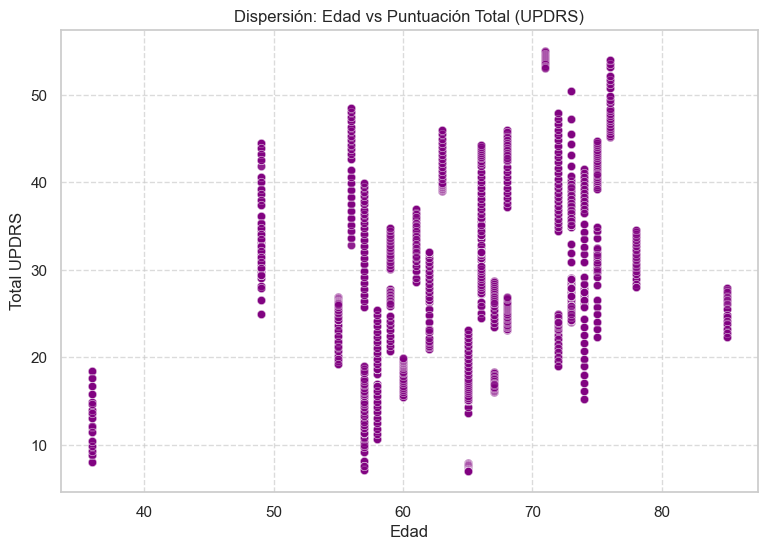

Gráfica de Barras (Top-10 Pacientes)


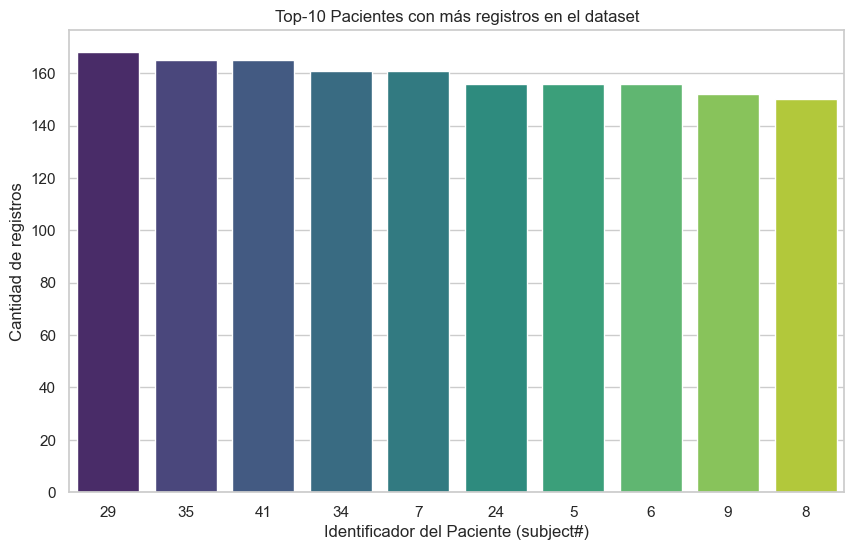

In [4]:
# Estilo limpio
sns.set_theme(style="whitegrid")
print("Histograma y Densidad (KDE) de 'age' ")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(df['age'], bins=15, color='skyblue', ax=ax[0])
ax[0].set_title('Histograma de la Edad (Age)')
ax[0].set_xlabel('Edad')
ax[0].set_ylabel('Frecuencia (Cantidad de registros)')

# Densidad (KDE)
sns.kdeplot(df['age'], fill=True, color='orange', ax=ax[1])
ax[1].set_title('Densidad (KDE) de la Edad')
ax[1].set_xlabel('Edad')
ax[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

# Boxplot
print("Boxplot para múltiples variables")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age', 'motor_UPDRS', 'total_UPDRS']], palette="Set2")
plt.title('Diagramas de Caja (Boxplots) para identificar valores atípicos')
plt.ylabel('Valores / Puntuación')
plt.show()

# Scatter Plot
print("Scatter Plot (Edad vs Total UPDRS)")
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='age', y='total_UPDRS', alpha=0.5, color='purple')

plt.title('Dispersión: Edad vs Puntuación Total (UPDRS)')
plt.xlabel('Edad')
plt.ylabel('Total UPDRS')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfica de barras
print("Gráfica de Barras (Top-10 Pacientes)")
plt.figure(figsize=(10, 6))
top10_pacientes = df['subject#'].value_counts().head(10)

sns.barplot(
    x=top10_pacientes.index.astype(str), 
    y=top10_pacientes.values, 
    hue=top10_pacientes.index.astype(str), 
    palette='viridis', 
    legend=False
)

plt.title('Top-10 Pacientes con más registros en el dataset')
plt.xlabel('Identificador del Paciente (subject#)')
plt.ylabel('Cantidad de registros')
plt.show()

Medición de Similitud y Disimilitud

 Paso 15: Selección de muestra (10 filas) 


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
5366,39,66,0,138.400,33.0840,43.563,0.00989,0.000070,0.00620,0.00419,...,0.329,0.02494,0.02016,0.02679,0.07481,0.049333,23.543,0.49315,0.64472,0.14389
4326,32,36,1,143.780,7.1599,12.060,0.00427,0.000024,0.00199,0.00263,...,0.208,0.00935,0.01128,0.01660,0.02806,0.013491,23.979,0.53244,0.63642,0.23252
199,2,58,0,10.815,11.2180,14.109,0.00970,0.000066,0.00510,0.00490,...,0.568,0.02949,0.03156,0.03813,0.08846,0.039924,18.384,0.49252,0.75548,0.23707
3260,24,60,0,39.828,12.7590,16.517,0.00924,0.000071,0.00335,0.00402,...,0.672,0.03767,0.04703,0.04819,0.11301,0.081412,14.349,0.78034,0.78442,0.34791
4955,36,62,1,103.310,25.3910,32.000,0.03199,0.000183,0.01681,0.02091,...,1.221,0.06463,0.07247,0.07086,0.19388,0.471650,6.092,0.71957,0.58285,0.46459
2550,19,55,0,81.731,18.0000,26.968,0.00823,0.000067,0.00392,0.00420,...,0.245,0.01269,0.01550,0.02127,0.03807,0.031999,20.454,0.65404,0.71500,0.33618
2764,20,67,0,39.844,11.4840,17.484,0.00297,0.000024,0.00137,0.00171,...,0.137,0.00681,0.00840,0.01228,0.02042,0.011709,24.210,0.51708,0.71164,0.16195
3386,25,76,0,20.398,25.2360,45.824,0.00411,0.000041,0.00219,0.00229,...,0.201,0.01200,0.01321,0.01779,0.03601,0.011601,22.307,0.56163,0.58720,0.17566
1212,9,68,0,112.410,17.9280,25.371,0.00561,0.000050,0.00225,0.00287,...,0.251,0.01113,0.01429,0.02514,0.03339,0.010953,22.327,0.59137,0.71825,0.25499
5015,37,56,1,49.841,28.0920,37.538,0.00525,0.000026,0.00305,0.00283,...,0.287,0.01636,0.01762,0.02061,0.04908,0.029912,22.987,0.42941,0.64624,0.18467


 Paso 16: Función Minkowski 
Distancia Manhattan (p=1) entre paciente 0 y 1: 87.43
Distancia Euclidiana (p=2) entre paciente 0 y 1: 50.64
 Paso 17: Matriz de Distancias 10x10 


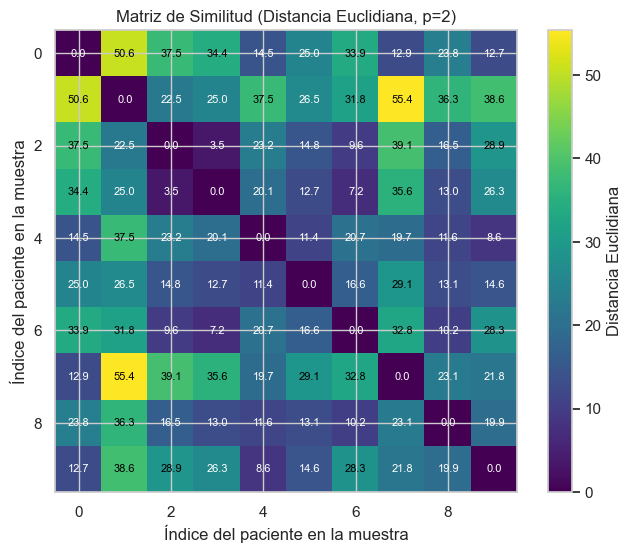

In [7]:
print(" Paso 15: Selección de muestra (10 filas) ")
# Seleccionamos 10 filas
muestra = df.sample(10, random_state=42)
# Muestra para comprobar
display(muestra)

print(" Paso 16: Función Minkowski ")
# Seleccionar variables
columnas_num = ['age', 'motor_UPDRS', 'total_UPDRS']
datos_muestra = muestra[columnas_num].values
# Función de Minkowski
def distancia_minkowski(x, y, p):
    """
    Calcula la distancia de Minkowski entre dos vectores x e y.
    Si p=1 es Manhattan, si p=2 es Euclidiana.
    """
    return np.sum(np.abs(x - y)**p)**(1/p)
fila_0 = datos_muestra[0]
fila_1 = datos_muestra[1]
dist_manhattan = distancia_minkowski(fila_0, fila_1, p=1)
dist_euclidiana = distancia_minkowski(fila_0, fila_1, p=2)
print(f"Distancia Manhattan (p=1) entre paciente 0 y 1: {dist_manhattan:.2f}")
print(f"Distancia Euclidiana (p=2) entre paciente 0 y 1: {dist_euclidiana:.2f}")

print(" Paso 17: Matriz de Distancias 10x10 ")
# 1. Matriz vacía de 10x10
n = len(datos_muestra) # Esto es 10
matriz_distancias = np.zeros((n, n))
# 2. Calcular la distancia (Euclidiana)
for i in range(n):
    for j in range(n):
        matriz_distancias[i, j] = distancia_minkowski(datos_muestra[i], datos_muestra[j], p=2)
# 3. Visualizar
plt.figure(figsize=(8, 6))
imagen = plt.imshow(matriz_distancias, cmap='viridis') 

plt.colorbar(imagen, label='Distancia Euclidiana')
plt.title('Matriz de Similitud (Distancia Euclidiana, p=2)')
plt.xlabel('Índice del paciente en la muestra')
plt.ylabel('Índice del paciente en la muestra')
for i in range(n):
    for j in range(n):
        # Cambiamos el color del texto a blanco o negro dependiendo del fondo para que se lea bien
        color_texto = "white" if matriz_distancias[i, j] < (matriz_distancias.max() / 2) else "black"
        plt.text(j, i, f"{matriz_distancias[i, j]:.1f}", ha="center", va="center", color=color_texto, fontsize=8)

plt.show()

Distancias para binarios

In [8]:
# Creamos una copia de la muestra para no alterar la original
muestra_bin = muestra.copy()
# Creamos la variable 'alto_UPDRS': 1 si es > 30, 0 si es <= 30
muestra_bin['alto_UPDRS'] = (muestra_bin['total_UPDRS'] > 30).astype(int)
columnas_binarias = ['sex', 'alto_UPDRS']
datos_binarios = muestra_bin[columnas_binarias].values
fila_0_bin = datos_binarios[0]
fila_1_bin = datos_binarios[1]

print(f"Fila 0 (Atributos Binarios): {fila_0_bin}")
print(f"Fila 1 (Atributos Binarios): {fila_1_bin}\n")


# Paso 18: Implementar Hamming
print("Paso 18: Distancia de Hamming")
def distancia_hamming(x, y):
    """Calcula la proporción de diferencias entre dos vectores binarios"""
    diferencias = np.sum(x != y)
    return diferencias / len(x)
    
dist_hamming = distancia_hamming(fila_0_bin, fila_1_bin)
print(f"Distancia de Hamming entre Fila 0 y Fila 1: {dist_hamming:.2f}")


# Paso 19: Implementar Jaccard 
print("\n Paso 19: Similitud de Jaccard")
def similitud_jaccard(x, y):
    """Calcula la similitud considerando solo las coincidencias de 1s"""
    # Intersección
    interseccion = np.sum((x == 1) & (y == 1))
    
    # Unión
    union = np.sum((x == 1) | (y == 1))
    
    # Prevenir división por cero
    if union == 0:
        return 0.0
    return interseccion / union
    
sim_jaccard = similitud_jaccard(fila_0_bin, fila_1_bin)
print(f"Similitud de Jaccard entre Fila 0 y Fila 1: {sim_jaccard:.2f}")

Fila 0 (Atributos Binarios): [0 1]
Fila 1 (Atributos Binarios): [1 0]

Paso 18: Distancia de Hamming
Distancia de Hamming entre Fila 0 y Fila 1: 1.00

 Paso 19: Similitud de Jaccard
Similitud de Jaccard entre Fila 0 y Fila 1: 0.00


Similitud Coseno

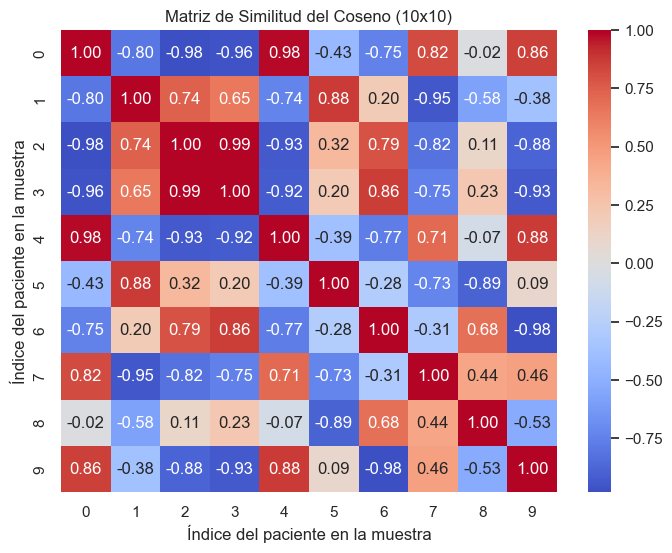

In [9]:
from scipy.stats import zscore
columnas_num = ['age', 'motor_UPDRS', 'total_UPDRS']
muestra_estandarizada = muestra[columnas_num].apply(zscore).values

# Implementar función de Coseno
def similitud_coseno(a, b):
    """Calcula la similitud del coseno entre dos vectores a y b"""
    producto_punto = np.dot(a, b)
    magnitud_a = np.linalg.norm(a)
    magnitud_b = np.linalg.norm(b)
    
    # Evitar división por cero
    if magnitud_a == 0 or magnitud_b == 0:
        return 0.0
    
    return producto_punto / (magnitud_a * magnitud_b)

# Construir matriz de similitud (10x10)
n = len(muestra_estandarizada)
matriz_coseno = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matriz_coseno[i, j] = similitud_coseno(muestra_estandarizada[i], muestra_estandarizada[j])

# Visualizar
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_coseno, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            xticklabels=range(10), yticklabels=range(10))
plt.title("Matriz de Similitud del Coseno (10x10)")
plt.xlabel("Índice del paciente en la muestra")
plt.ylabel("Índice del paciente en la muestra")
plt.show()

Distancia para Tipos Mixtos

 5.4 Distancia para Tipos Mixtos 


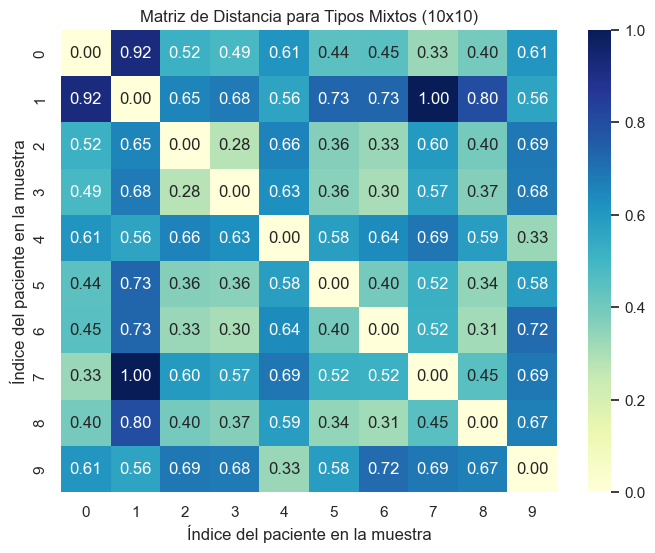

In [10]:
print(" 5.4 Distancia para Tipos Mixtos ")
cols_num = ['age', 'total_UPDRS']
cols_cat = ['sex', 'subject#']

# Normalizar
muestra_num_norm = muestra[cols_num].copy()
for col in cols_num:
    min_val = muestra_num_norm[col].min()
    max_val = muestra_num_norm[col].max()
    if max_val != min_val:
        muestra_num_norm[col] = (muestra_num_norm[col] - min_val) / (max_val - min_val)
    else:
        muestra_num_norm[col] = 0.0
datos_num_norm = muestra_num_norm.values
datos_cat = muestra[cols_cat].values

# Función para Tipos Mixtos
def distancia_mixta(num1, num2, cat1, cat2):
    """Calcula la distancia combinando numéricas y categóricas"""
    dist_num = np.abs(num1 - num2)
    dist_cat = np.array([0 if c1 == c2 else 1 for c1, c2 in zip(cat1, cat2)])
    
    distancia_total = (np.sum(dist_num) + np.sum(dist_cat)) / (len(num1) + len(cat1))
    return distancia_total

# Construir matriz 10x10
matriz_mixta = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matriz_mixta[i, j] = distancia_mixta(datos_num_norm[i], datos_num_norm[j], 
                                             datos_cat[i], datos_cat[j])

# Visualizar
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_mixta, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Matriz de Distancia para Tipos Mixtos (10x10)")
plt.xlabel("Índice del paciente en la muestra")
plt.ylabel("Índice del paciente en la muestra")
plt.show()